# Practical session 4 - K-nearest neighbours (K-NN) classification with numpy, scikit-learn, cython and numba

Students (pair):
- [Moulahi Amine](https://github.com/Moul4)
- [Saglier Valentin](https://github.com/valentin-sgl)

**Useful references for this lab**:

[1] scikit-learn: [documentation](https://scikit-learn.org/stable/modules/neighbors.html?highlight=knn%20classification)

[2] `numba`: [documentation](http://numba.pydata.org/) 

[3] cython: [a very useful tutorial](https://cython.readthedocs.io/en/latest/src/userguide/numpy_tutorial.html#numpy-tutorial), and [another one](http://docs.cython.org/en/latest/src/tutorial/cython_tutorial.html)



## <a name="content">Contents</a>
- [Exercise 1: KNN classification with numpy and sklearn](#ex1)
- [Exercise 2: Code acceleration with cython](#ex2)
- [Exercise 3: Code acceleration with numba](#ex3)
---

In [1]:
%load_ext autoreload
%autoreload 2

## <a name="ex1">Exercise 1: K-Nearest Neighbours (K-NN) classification with numpy and scikit-learn</a> [(&#8593;)](#content)

This session is a first introduction to classification using the most intuitive non parametric method: the $K$-nearest neighbours. The principle is [the following](https://scikit-learn.org/stable/modules/neighbors.html?highlight=knn%20classification). A set of labelled observations is given as a learning set. A classification taks then consists in assigning a label to any new observation. In particular, the K-NN approach consists in assigning to the observation the most frequent label among its $K$ nearest neighbours taken in the training set.

### A. Validation on synthetic data

Load the training and test datasets `data/synth_train.txt` and `data/synth_test.txt`. Targets belong to the set $\{1,2\}$ and entries belong to $\mathbb{R}^2$. The file `data/synth_train.txt` contain 100 training data samples, and `data/synth_test.txt` contains 200 test samples, where:

- the 1st column contains the label of the class the sample;
- columns 2 & 3 contain the coordinates of each sample (in $\mathbb{R}^2$).

Useful commands can be found below.

```python
# load the training set
train = np.loadtxt('data/synth_train.txt')  #...,delimiter=',') if there are ',' as delimiters
class_train = train[:,0]
x_train = train[:,1:]
N_train = train.shape[0]
```

```python
# load the test set
test = np.loadtxt('/datasynth_test.txt') 
class_test_1 = test[test[:,0]==1]
class_test_2 = test[test[:,0]==2]
x_test = test[:,1:]
N_test = test.shape[0]
```

1\. Display the training set and distinguish the two classes. 

> Hint: useful functions include `matplotlib.pyplot.scatter` or `matplotlib.pyplot.plot`.

**Answer:**

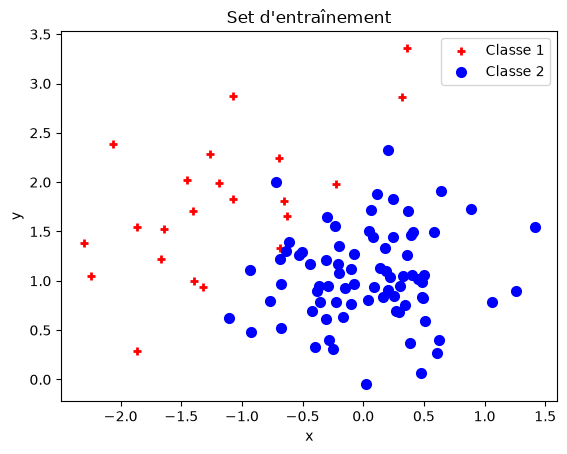

In [2]:
import numpy as np
import matplotlib.pyplot as plt

 # load the training set
train = np.loadtxt('data/synth_train.txt')  #...,delimiter=',') if there are ',' as delimiters
class_train = train[:,0]
x_train = train[:,1:]
N_train = train.shape[0]

test = np.loadtxt('data/synth_test.txt')
class_test = test[:,0]
x_test = test[:,1:]
N_test = test.shape[0] 

plt.scatter(x_train[class_train == 1, 0], x_train[class_train == 1, 1], marker='+', color='red', linewidth=2, label="Classe 1") # on trace uniquement les points de la classe 1
plt.scatter(x_train[class_train == 2, 0], x_train[class_train == 2, 1], marker='o', color='blue', linewidth=2, label="Classe 2") # on trace uniquement les points de la classe 2
plt.title("Set d'entraînement")
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

2\. Implement the K-nearest neighbours algorithm for classification.

> Hint: 
> - useful functions include `numpy.linalg.norm`, `numpy.argsort`, `numpy.bincount`;
> - implement the algorithm as a function rather than an object. This will drastically simplify the acceleration step using Cython.
> - for an optimized partial sorting procedure, you may have a look at the [`bottleneck.argpartition` function](https://bottleneck.readthedocs.io/en/latest/reference.html#bottleneck.argpartition).
> 1. Compute for each row in `x_test` (if necessary use `np.newaxis`) its distance with respect to `x_train`:
>  - Use  `numpy.linalg.norm` (in which dimension this distance is computed ? Consider using `axis` argument)
> 2. Sort the ordered collection of distances (indices from smallest to largest (in ascending order) by the distances):
>   - Use `np.argsort` (at the end replace this procedure by `bottleneck.argpartition`)
>   - Once the sorting is done, we take only the indices of `labels` of the `n_neighbours` nearest neighbours of the `class_train` :
>     - `id = np.argsort(distances)[:n_ neighbours]` and `labels = class_train[id]`
> 3. The K-nearest can be used for **Regression**, in this case it is necessary to return the mean of the K-labels. For **Classification**,  we return the mode of the K-labels :
> - Use `np.bincount` for `labels` to affect the variable `class_pred[q]` (for row `q`). This procedure counts the number of occurrences of each value in array. **Mode** is the value that appears. How can we get this value ?


```python
import numpy as np
import bottleneck as bn

# Create a random array
arr = np.random.rand(10)
N = 3  # Number of smallest elements to retrieve

# Using np.argsort() to get indices of the first N elements
sorted_indices = np.argsort(arr)[:N]

# Using bottleneck.argpartition() to get the first N smallest indices
partitioned_indices = bn.argpartition(arr, N)[:N]

# Display the results
print("Original array:", arr)
print("Indices using np.argsort:", sorted_indices)
print("First N elements using np.argsort:", arr[sorted_indices])

print("Indices using bottleneck.argpartition:", partitioned_indices)
print("First N elements using bottleneck.argpartition:", arr[partitioned_indices])

are_equal = set(arr[sorted_indices]) == set(arr[partitioned_indices])
print(are_equal)
```


**Answer:**

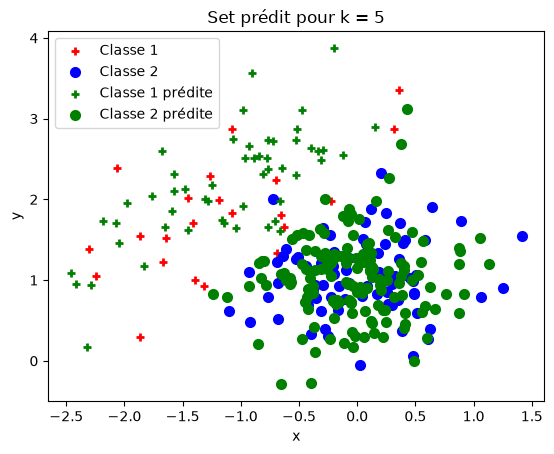

In [3]:
import bottleneck as bn

def knn_algorithm(x_train, class_train, x_test, k) :
    predict_classe = np.zeros(N_test, dtype=int) # on initialise le vecteur de prédiction des classes à 0

# On calcule la distance entre chaque point de test et tous les points d'entraînement, puis on sélectionne les k plus proches voisins pour déterminer la classe prédite pour chaque point de test.
    for i in range(N_test) :
        diff = x_train - x_test[i, np.newaxis] # On utilise np.newaxis pour ajouter une dimension à x_test[i], ce qui permet de soustraire correctement les coordonnées du point de test à toutes les coordonnées des points d'entraînement.
        distances = np.linalg.norm(diff, axis=1)

        knn = bn.argpartition(distances, k)[:k] # On utilise argpartition pour trouver les indices des k plus petites distances, ce qui est plus efficace que de trier toutes les distances.

        classes = class_train[knn]

        predict_classe[i] = np.argmax(np.bincount(classes.astype(int))) # On utilise bincount pour compter le nombre d'occurrences de chaque classe parmi les k plus proches voisins, puis argmax pour trouver la classe la plus fréquente.

    return predict_classe

# On teste notre algorithme pour k=5
y_pred = knn_algorithm(x_train, class_train, x_test, 5)

plt.scatter(x_train[class_train == 1, 0], x_train[class_train == 1, 1], marker='+', color='red', linewidth=2, label="Classe 1")
plt.scatter(x_train[class_train == 2, 0], x_train[class_train == 2, 1], marker='o', color='blue', linewidth=2, label="Classe 2")

# Les points verts correspondent aux points de test prédits
plt.scatter(x_test[y_pred == 1, 0], x_test[y_pred == 1, 1], marker='+', color='green', linewidth=2, label="Classe 1 prédite")
plt.scatter(x_test[y_pred == 2, 0], x_test[y_pred == 2, 1], marker='o', color='green', linewidth=2, label="Classe 2 prédite")

plt.title("Set prédit pour k = 5")
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()


3\. Compute the error rate on the training set and the test set for $K \in \{1,2, \dotsc, 20\}$. Display the classification result (see 1.) for the configuration with the lowest error rate.

**Answer:**

Le k optimal est k = 3, avec un taux d'erreur de 4.5%


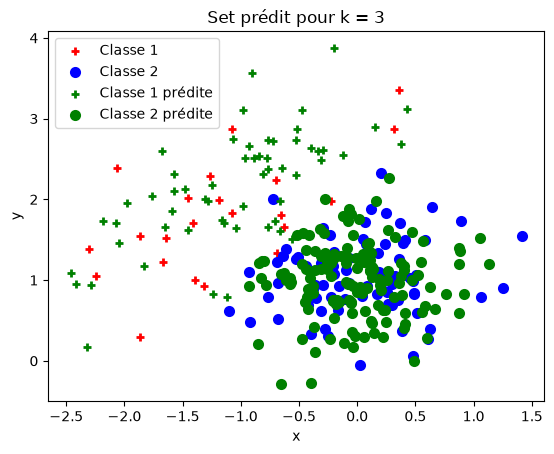

In [4]:
# On cherche le k optimal en testant les valeurs de k de 1 à 20 et en calculant le taux d'erreur pour chaque valeur de k.
K = np.arange(1, 21)

# Taux d'erreur pour chaque valeur de k
test_errors = []

for i in K :
    pred_test = knn_algorithm(x_train, class_train, x_test, i) # on prédit les classes pour le set de test avec k=i
    erreur = np.mean(pred_test != class_test) # on compare les classes prédites avec les classes réelles et on calcule le taux d'erreur
    test_errors.append(erreur)

# On trouve le k avec le taux d'erreur le plus bas
k_opti_position = np.argmin(test_errors)
k_opti = K[k_opti_position]

erreur_opti = test_errors[k_opti_position]

print(f"Le k optimal est k = {k_opti}, avec un taux d'erreur de {erreur_opti*100}%")

# On applique notre fonction et on trace le graphe pour k optimal
y_pred = knn_algorithm(x_train, class_train, x_test, k_opti)

plt.scatter(x_train[class_train == 1, 0], x_train[class_train == 1, 1], marker='+', color='red', linewidth=2, label="Classe 1")
plt.scatter(x_train[class_train == 2, 0], x_train[class_train == 2, 1], marker='o', color='blue', linewidth=2, label="Classe 2")
plt.scatter(x_test[y_pred == 1, 0], x_test[y_pred == 1, 1], marker='+', color='green', linewidth=2, label="Classe 1 prédite")
plt.scatter(x_test[y_pred == 2, 0], x_test[y_pred == 2, 1], marker='o', color='green', linewidth=2, label="Classe 2 prédite")
plt.title(f"Set prédit pour k = {k_opti}")
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()


4\. Comment on your results. Which value of $K$ seems optimal ?


**Answer:**

In [5]:
print(f"Le k optimal est k = {k_opti}, avec un taux d'erreur de {erreur_opti*100}%")

Le k optimal est k = 3, avec un taux d'erreur de 4.5%


5\. Compare the results of you implementation with those of [`sklearn.neighbors.KNeighborsClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html?highlight=kneighborsclassifier#sklearn.neighbors.KNeighborsClassifier). Compare the runtime of these two versions using the [`timeit`](https://docs.python.org/3/library/timeit.html) module (see session 1).

**Answer:**

In [6]:
from sklearn.neighbors import KNeighborsClassifier

test_errors_sk = []

for i in K :
    knn_sk = KNeighborsClassifier(n_neighbors=i)
    knn_sk.fit(x_train, class_train)

    pred_test_sk = knn_sk.predict(x_test)

    erreur_sk = np.mean(pred_test_sk != class_test)
    test_errors_sk.append(erreur_sk)

k_opti_position_sk = np.argmin(test_errors_sk)
k_opti_sk = K[k_opti_position_sk]

# On compare les résultats de notre algorithme avec ceux de sklearn
compar_algo = test_errors_sk[k_opti_position]
erreur_opti_sk = test_errors_sk[k_opti_position_sk]

print(f"Dans le cas optimal de la question 3 avec le knn_algorithm (k = {k_opti}, taux d'erreur = {erreur_opti*100}%), nous avons un taux d'erreur de {compar_algo*100}% avec sklearn.")
print(f"Avec sklearn, le k optimal est k = {k_opti_sk}, avec un taux d'erreur de {erreur_opti_sk*100}%.")

# On affiche maintenant le temps de traitement de notre algorithme et celui de sklearn pour k optimal.
print("\nTemps de traitement de knn_algorithm :")
%timeit -n 100 -r 7 knn_algorithm(x_train, class_train, x_test, k_opti)

def eval_sklearn():
    knn_sk = KNeighborsClassifier(n_neighbors=k_opti)
    knn_sk.fit(x_train, class_train)
    knn_sk.predict(x_test)
print("Temps de traitement de KNeighborsClassifier :")
%timeit -n 100 -r 7 eval_sklearn()

Dans le cas optimal de la question 3 avec le knn_algorithm (k = 3, taux d'erreur = 4.5%), nous avons un taux d'erreur de 4.5% avec sklearn.
Avec sklearn, le k optimal est k = 3, avec un taux d'erreur de 4.5%.

Temps de traitement de knn_algorithm :
2.78 ms ± 25.4 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
Temps de traitement de KNeighborsClassifier :
1.83 ms ± 18.4 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


### B. Application to a real dataset (Breast cancer Wisconsin).

6\. Apply the K-NN classifier to the real dataset `data/wdbc12.data.txt.` Further details about the data are provided in `data/wdbc12.names.txt`.

> Hint: you can use the function [`train_test_split` from `sklearn.model_selection`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) to split the dataset into a training and a test set.

**Answer:**

In [7]:
from sklearn.model_selection import train_test_split

dataset = np.loadtxt('data/wdbc12.data.txt', delimiter=',')

train_data, test_data = train_test_split(dataset, test_size=0.2, random_state=0)
class_train_data = train_data[:,1]
x_train_data = train_data[:,2:]
N_train_data = train_data.shape[0]

class_test_data = test_data[:,1]
x_test_data = test_data[:,2:]

test_errors_data = []

for i in K :
    knn_data = KNeighborsClassifier(n_neighbors=i)
    knn_data.fit(x_train_data, class_train_data)

    pred_test_data = knn_data.predict(x_test_data)

    erreur_data = np.mean(pred_test_data != class_test_data)
    test_errors_data.append(erreur_data)

k_opti_position_data = np.argmin(test_errors_data)
k_opti_data = K[k_opti_position_data]

erreur_opti_data = test_errors_data[k_opti_position_data]

print(f"Le k optimal est k = {k_opti_data}, avec un taux d'erreur de {round(erreur_opti_data*100, 2)}%")

Le k optimal est k = 9, avec un taux d'erreur de 3.51%


## <a name="ex2">Exercise 2: Code acceleration with cython</a> [(&#8593;)](#content)

Cython allows C code to be easily interfaced with Python. It can be useful to make your code faster for a small coding effort, in particular when using loops. A general approach to optimize your code is outlined in the [Scipy lecture notes, Section 2.4](https://scipy-lectures.org/advanced/optimizing/index.html). Complementary reading about interfacing Python with C can be found in [Section 2.8](https://scipy-lectures.org/advanced/interfacing_with_c/interfacing_with_c.html).

1\. Read carefully the [cython tutorial](http://docs.cython.org/en/latest/src/tutorial/cython_tutorial.html), which describes step by the step how the toy example reported below has been developed.

**Setup**: Compile the toy example provided in `example_cy/` by running, in the command line (anaconda prompt on windows)

```bash
cd example_cy && python setup.py build_ext --inplace
```

Note that the compilation process has been slightly automatised with the instructions reported in `example_cy/setup.py`. To test the module, run

In [8]:
!cd example_cy && python setup.py build_ext --inplace

running build_ext


In [9]:
import example_cy.helloworld as toy

toy.printhello()

Hello World


which should display
```python
Hello World
```

> Warning: 
> - do not forget to include an empty `__init__.py` file in the directory where your source code lives (`import` will fail if this is not the case).
> - in case you have any setup issue, take a look at the `notes.md` file.
> - if the C code and/or the executable do not seem to be regenerated by the build instructions, delete the C code and the executable first, and re-execute the compilation afterwards.
> - do not hesitate to restart the Python kernel if necessary when the Cython executable has been re-generated.

2\. Read the [Numpy/Cython tutorial](https://cython.readthedocs.io/en/latest/src/userguide/numpy_tutorial.html#numpy-tutorial), focussing on the paragraphs **Cython at a glance**, and **Your Cython environment** until **"More generic code"**. An example to compile a `.pyx` file depending on `numpy` is included in `example_np_cy/`.

> Remarks: 
> - the `annotate=True` flag in the `setup.py` allows an additional `.html` document to be generated (`<your_module_name>.html`), showing, for each line of the Cython code, the associated C instructions generated. Highlighted in yellow are the interactions with Python: the darker a region appears, the less efficient the generated C code is for this section. Work in priority on these! 
> - make sure all the previously generated files are deleted to allow the .html report to be generated;
> - if you are working on your own machine and don't have a C/C++ compiler installed, read the notes provided in `notes.md`;
> - use `cdef` for pure C functions (not exported to Python), `cpdef` should be favored for functions containing C instructions and later called from Python.

**Answer:**

In [10]:
!cd example_np_cy && python setup.py build_ext --inplace

import example_np_cy.compute_cy as compute_cy

Compiling knn_cy.pyx because it changed.
[1/1] Cythonizing knn_cy.pyx
running build_ext
building 'knn_cy' extension
"C:\Program Files\Microsoft Visual Studio\18\Community\VC\Tools\MSVC\14.51.36231\bin\HostX86\x64\cl.exe" /c /nologo /O2 /W3 /GL /DNDEBUG /MD -Ic:\Users\valen\Documents\Python\.venv\Lib\site-packages\numpy\_core\include -Ic:\Users\valen\Documents\Python\.venv\include -IC:\Users\valen\AppData\Local\Programs\Python\Python313\include -IC:\Users\valen\AppData\Local\Programs\Python\Python313\Include "-IC:\Program Files\Microsoft Visual Studio\18\Community\VC\Tools\MSVC\14.51.36231\include" "-IC:\Program Files\Microsoft Visual Studio\18\Community\VC\Tools\MSVC\14.51.36231\ATLMFC\include" "-IC:\Program Files\Microsoft Visual Studio\18\Community\VC\Auxiliary\VS\include" "-IC:\Program Files (x86)\Windows Kits\10\include\10.0.26100.0\ucrt" "-IC:\Program Files (x86)\Windows Kits\10\\include\10.0.26100.0\\um" "-IC:\Program Files (x86)\Windows Kits\10\\include\10.0.26100.0\\shared" "-I

3\. Use Cython to implement a faster version of the numpy K-NN classifier implemented in [Exercise 1](#ex1). To do so, apply step-by-step the techniques introduced in the [Numpy/Cython tutorial](https://cython.readthedocs.io/en/latest/src/userguide/numpy_tutorial.html#numpy-tutorial) (*i.e.*, compile and time your code after each step to report the evolution, keeping track of the different versions of the cython function).

> Hint: if you keep numpy arrays, make sure you use memory views (see numpy/cython tutorial) to access the elements within it. Be extremely careful with the type of the input arrays (you may need to recast the format of the input elements before entering the function. The `numpy.asarray` function can prove useful).

> **Detailed guidelines**: a few notes and *caveat* to help you re-writing your code in cython:
> - try to reduce the number of calls to numpy instructions as much as possible;
> - **you do not have to optimize everything**. For the KNN function above, most of the time is spent in computing euclidean distances: you can thus focus on optimizing tihs operations by explicitly writing a for loop, which will ensure a minimal interaction with numpy when generating the associated C code at compilation. Calls to other numpy functions can be kept as-is;
> - if you need to create an array within the cython function, used np.zeros (**do NOT use python lists**), and use a memory view to access its content;
> - specify the type for all variables and numpy arrays. Pay attention to the type of the input arrays passed to the Cython function;
> - whenever an array is returned, use memory views and index(es) to efficiently access its content;
> - some numpy operators (e.g., broadcasting mechanism) do not work with memory views. In this case, you can directly write for loop(s) to encode the operation of interest (the loops will be optimized out at compile time);
> - only use at the final development stage the following cython optimization (not before, as they can crash the program without any help):
>
>```python
>@cython.boundscheck(False)
>@cython.wraparound(False)
>```

**Answer:**

In [11]:
# On compile les fichiers .pyx
!cd example_np_cy && python setup.py build_ext --inplace

# On importation le module Cython
import example_np_cy.knn_cy as cy_knn

# On prépare les tableaux au format contigu
x_train_c = np.ascontiguousarray(x_train, dtype=np.float64)
class_train_c = np.ascontiguousarray(class_train, dtype=np.float64)
x_test_c = np.ascontiguousarray(x_test, dtype=np.float64)

# On exécute avec le k optimal trouvé précédemment
k_val = k_opti

# On exécute les fonctions Python et Cython avec le jeu de données synthétique
pred_python = knn_algorithm(x_train, class_train, x_test, k_val)
pred_cython_avec_secu = cy_knn.knn_cython_avec_secu(x_train_c, class_train_c, x_test_c, k_val) # fonction avec le mécanisme de sécurité de Cython
pred_cython_sans_secu = cy_knn.knn_cython_sans_secu(x_train_c, class_train_c, x_test_c, k_val) # fonction sans le mécanisme de sécurité de Cython

# On vérifie que les prédictions sont bien identiques
print("Résultats identiques entre Python et Cython avec sécurité :", np.array_equal(pred_python, pred_cython_avec_secu))
print("Résultats identiques entre Python et Cython sans sécurité :", np.array_equal(pred_python, pred_cython_sans_secu))

running build_ext
Résultats identiques entre Python et Cython avec sécurité : True
Résultats identiques entre Python et Cython sans sécurité : True


4\. Compare the runtime of the two algorithms (using `timeit.timeit`), and conclude about the interest of using cython in this case.

**Answer:**

In [12]:
import timeit
print("Comparaison des temps d'exécution")

# Fonction de base
time_knn_initial = timeit.timeit(lambda: knn_algorithm(x_train, class_train, x_test, k_val), number=100)
print(f"\ntemps d'exécution KNN_algorithm : {time_knn_initial:.3f} secondes")

# Version Cython avec la sécurité (Memory Views)
time_knn_cython_avec_secu = timeit.timeit(lambda: cy_knn.knn_cython_avec_secu(x_train_c, class_train_c, x_test_c, k_val), number=100)
print(f"\ntemps d'exécution KNN_algorithm (Cython avec sécurité) : {time_knn_cython_avec_secu:.3f} secondes")

# Version Cython sans la sécurité (Optimisations finales avec décorateurs)
time_knn_cython_sans_secu = timeit.timeit(lambda: cy_knn.knn_cython_sans_secu(x_train_c, class_train_c, x_test_c, k_val), number=100)
print(f"\ntemps d'exécution KNN_algorithm (Cython sans sécurité) : {time_knn_cython_sans_secu:.3f} secondes")

Comparaison des temps d'exécution

temps d'exécution KNN_algorithm : 0.319 secondes

temps d'exécution KNN_algorithm (Cython avec sécurité) : 0.105 secondes

temps d'exécution KNN_algorithm (Cython sans sécurité) : 0.093 secondes


## <a name="ex3">Exercise 3: Code acceleration with numba</a> [(&#8593;)](#content)

`numba` is a just-in-time (JIT) compiler which translates Python codes into efficient machine code at runtime. A significant acceleration can be obtained by adding a few simple decorators to a standard Python function, up to a few restrictions detailed [here](http://numba.pydata.org/numba-doc/latest/user/performance-tips.html).

If you have written most of the KNN classifier of exercise 1 with numpy, there is little to no chance that you will get an acceleration with numba (justifying the use of cython in this case). An interesting acceleration factor can however be obtained for the computation of the total variation investigated in session 2.

1\. Take a look at the [numba 5 min tour](http://numba.pydata.org/numba-doc/latest/user/5minguide.html), and accelerate the total variation code from session 2 with the `@jit` decorator. You may have to rewrite small portions of your code to get the expected acceleration (see [performance tips](http://numba.pydata.org/numba-doc/latest/user/performance-tips.html)).

**Answer:**

In [13]:
from numba import njit
import numpy as np

@njit
def tv_numba(X):
    """
    Version optimisée avec Numba de la variation totale 2D.
    On calcule directement les différences finies et leurs normes dans des boucles C.
    """
    M, N = X.shape
    tv_sum = 0
    
    for i in range(M):
        for j in range(N):
            # Différence horizontale (dx)
            if j < N - 1:
                dx = X[i, j+1] - X[i, j]
            else:
                dx = 0.0
                
            # Différence verticale (dy)
            if i < M - 1:
                dy = X[i+1, j] - X[i, j]
            else:
                dy = 0
                
            # Norme L2 locale (TV isotrope : sqrt(|dx|^2 + |dy|^2))
            # Utilisation de abs() pour gérer nativement les réels ou complexes
            tv_sum += np.sqrt(abs(dx)**2 + abs(dy)**2)
            
    return tv_sum

2\. Compare the runtime of the your numpy implementation and the `numba`-accelerated version (using `timeit.timeit`). 
> **Warning**: first run the numba version once to trigger the compilation, and then time it as usual. This is needed to avoid including the JIT compilation step in the runtime.

**Answer:**

In [14]:
# fonctions du lab2
def gradient2D(X) :
    """
    Calcule l'opérateur de gradient discret 2D (D) appliqué à une matrice X.
    Cette fonction calcule les différences finies horizontales et verticales d'un tableau 2D, en préservant les dimensions spatiales d'origine grâce à l'ajout de zéros aux frontières.

    Paramètres :
        X : array_like
        X est une matrice 2D d'entrée de dimension (M, N), qui peut contenir des nombres réels ou complexes.

    Retours :
        grad : numpy.ndarray
        grad est un tableau 3D de dimension (2, M, N) représentant le gradient 2D de X.
        - grad[0, :, :] contient les différences horizontales (dx).
        - grad[1, :, :] contient les différences verticales (dy).

    Lève :
        AssertionError
        Si le tableau d'entrée X possède plus de 2 dimensions.
    """

    #On convertit l'entrée en tableau numpy si ce n'est pas déjà le cas
    X = np.asarray(X)

    M, N = X.shape  # M = nombre de lignes, N = nombre de colonnes

    #Différences horizontales : X[: i+1] - X[: i]
    #np.c_ ajoute une colonne de zéros à la fin
    dx = np.c_[np.diff(X, axis=1), np.zeros((M, 1), dtype=X.dtype)] #dtype permet de conserver le type de valeur initial de X, et ainsi traiter les nombres complexes

    #Différences verticales : X[i+1 :] - X[i :]
    #np.r_ ajoute une ligne de zéros en bas
    dy = np.r_[np.diff(X, axis=0), np.zeros((1, N), dtype=X.dtype)] #dtype permet de conserver le type de valeur initial de X, et ainsi traiter les nombres complexes

    #Concaténation de dx et dy en un tableau 3D de dimension (2, M, N)
    return np.array([dx, dy])

def tv(X):
    """
    On calcule la variation totale (TV) isotrope d'une matrice X.

    La TV correspond à la somme des normes du gradient en chaque point de la matrice.
    Pour des valeurs complexes, la magnitude est calculée via le module des nombres complexes.

    Paramètres :
        X : array_like
        X est une matrice 2D d'entrée de dimension (M, N), qui peut contenir des nombres réels ou complexes.

    Retours :
        float
        La valeur scalaire de la TV.
    """
    #On calcul le gradient 2D avec la fonction gradient2D
    grad = gradient2D(X)

    #On calcul la norme du gradient en chaque élément (TV isotrope)
    # np.linalg.norm avec axis=0 calcule sqrt(|dx|^2 + |dy|^2) en chaque point
    normes_element = np.linalg.norm(grad, axis=0)

    # La variation totale est la somme globale de ces normes
    return np.sum(normes_element)


test = np.random.rand(1000, 1000)  # Exemple de matrice aléatoire

_ = tv_numba(test)  # On exécute une fois pour compiler la fonction numba avant de mesurer le temps

# Comparaison des performances
print("Comparaison des temps d'exécution")

# Fonction numpy
time_lab2 = timeit.timeit(lambda: tv(test), number=100)
print(f"\ntemps d'exécution base TV lab2 : {time_lab2:.3f} secondes")

# Version Cython avec la sécurité (Memory Views)
time_numba = timeit.timeit(lambda: tv_numba(test), number=100)
print(f"\ntemps d'exécution TV avec numba : {time_numba:.3f} secondes")


Comparaison des temps d'exécution

temps d'exécution base TV lab2 : 2.854 secondes

temps d'exécution TV avec numba : 0.219 secondes
